#### Summary:
For the paper we want to have lists of cell type specific genes, cREs, and motifs. To accomplish this I'm adapting a straightforward method used by Kai in a recent paper (). After looking through it, they seem to calculate entropy and then do some background permutations to assign significance. For our purposes here, for now I'm just going to calculate entropy and then pick an entropy value cutoff. I first did this for cREs, but I'll also do it for genes and motifs (using the per-donor ChromVAR means I made for plotting). I could also run HOMER on the entropy cREs instead of ChromVAR, but we'll see how it goes.

I somehow don't have cell type pseudobulked CPM values, only separated by donor, for the final object. For multiple reasons this would be helpful, so just gonna quickly regenerate that matrix here. 

Reference notebooks:
- `/nfs/lab/hmummey/multiomic_islet/notebooks/trait_associations/240313_ATAC_DESeq_Trait_Associations_v3_wHPAP_Prep.ipynb`
- `/nfs/lab/hmummey/multiomic_islet/notebooks/trait_associations/final_notebooks/1_RNA%2BATAC_associations_prep.ipynb`

In [1]:
suppressMessages(library(hdf5r))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))

suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(data.table))
suppressMessages(library(tictoc))

suppressMessages(library(ggplot2))
suppressMessages(library(ggpubr))
suppressMessages(library(readr))
#suppressMessages(library(pheatmap))
#suppressMessages(library(pracma))
#suppressMessages(library(GenomicRanges))

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Warning message:
“package ‘sp’ was built under R version 4.3.3”
Warning message:
“package ‘dplyr’ was built under R version 4.3.2”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘tictoc’ was built under R version 4.3.3”
Warning message:
“package ‘ggpubr’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”


In [2]:
library(readr)

In [ ]:
suppressMessages(library('DescTools'))

In [4]:
joint_celltypes <- c('Hepatocytes.Senescent', 'Hepatocytes.Stress',
                     'Hepatocytes.Zone1','Hepatocytes.Zone2','Hepatocytes.Zone3')

In [5]:
outdir <- '/nfs/lab/mkim/Liver_Multiome/downstream/entropy_outputs/Hepatocytes'

# Calculate entropy of genes using TPM tables

In [6]:
#read in the all cell types TPM matrix
tpm <- read.table("/nfs/lab/mkim/Liver_Multiome/downstream/count.matrices/Hepatocytes_RNA/Hepatocytes.cellsubtype.RNA.TPM.tsv", 
                  sep='\t', header=T)
tpm <- tpm[,joint_celltypes]
head(tpm)

#remove any genes not expressed in any cell type
not_expressed <- row.names(tpm[rowSums(tpm)==0,])
length(not_expressed)
tpm_fin <- tpm[rowSums(tpm)>0,]

,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MIR1302-2HG,1.64344802,0.00000000,0.54223476,0.833342219,0.7846500
FAM138A,0.00000000,0.00000000,0.00000000,0.000000000,0.0000000
OR4F5,0.00000000,0.00000000,0.06879777,0.002800263,0.0000000
AL627309.1,1.46295319,1.65099339,1.43721747,1.346286690,1.3767858
AL627309.3,1.61881606,0.03271147,0.19103977,1.022852002,1.6817759
AL627309.2,0.05098693,0.00000000,0.13070944,0.125412783,0.3812278


[1] 1682

In [7]:
head(tpm_fin)

,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MIR1302-2HG,1.64344802,0.00000000,0.54223476,0.833342219,0.7846500
OR4F5,0.00000000,0.00000000,0.06879777,0.002800263,0.0000000
AL627309.1,1.46295319,1.65099339,1.43721747,1.346286690,1.3767858
AL627309.3,1.61881606,0.03271147,0.19103977,1.022852002,1.6817759
AL627309.2,0.05098693,0.00000000,0.13070944,0.125412783,0.3812278
AL627309.5,2.65367522,2.13083357,3.28476519,3.068296636,3.2425156


In [8]:
#convert TPM values to prob values (based on rowSums)
probs <- list()
rowsums <- rowSums(tpm_fin)

for(celltype in joint_celltypes){
    probs[[celltype]] <- tpm_fin[,celltype]/rowsums
}

prob_df <- as.data.frame(probs)
head(prob_df)

,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MIR1302-2HG,0.43206846,0.000000000,0.14255549,0.2190887,0.2062874
OR4F5,0.00000000,0.000000000,0.96088910,0.0391109,0.0000000
AL627309.1,0.20111433,0.226964491,0.19757640,0.1850760,0.1892688
AL627309.3,0.35600320,0.007193768,0.04201266,0.2249413,0.3698491
AL627309.2,0.07407264,0.000000000,0.18989165,0.1821968,0.5538389
AL627309.5,0.18453820,0.148179471,0.22842458,0.2133712,0.2254865


[1] 2.321888

[1] 0

[1] 3.169925


FALSE  TRUE 
31427  3492 

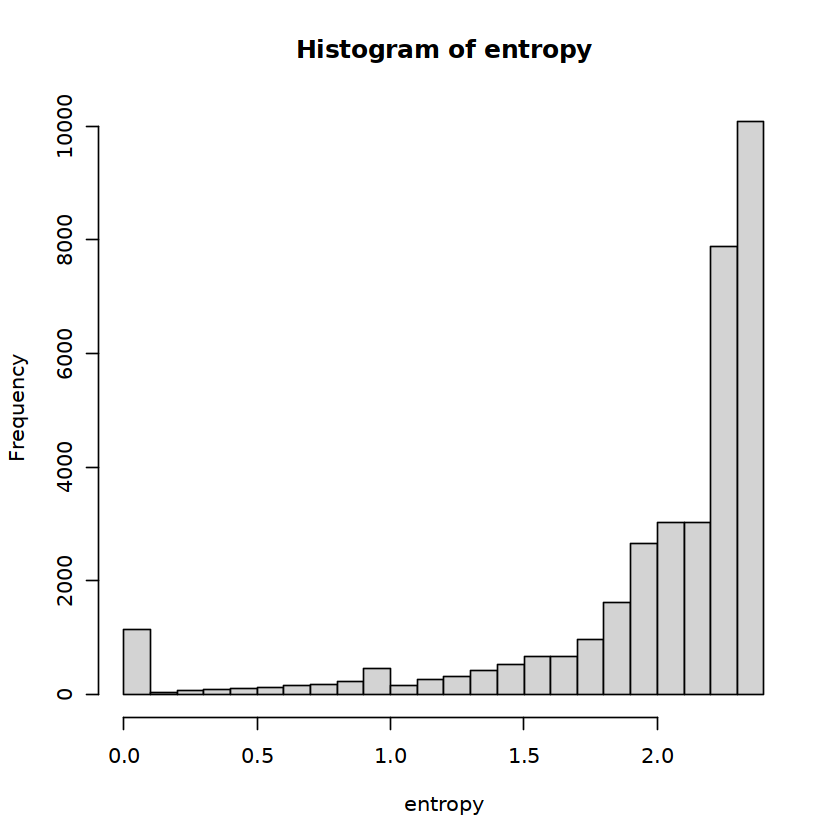

In [9]:
#calculate entropy with DescTools::Entropy function
entropy <- apply(prob_df, 1, Entropy)
hist(entropy)
max(entropy)
min(entropy)
log2(9)

entropy_cutoff <- unname(quantile(entropy, probs = 0.1, na.rm = TRUE))
table(entropy < entropy_cutoff)

In [59]:
#calculate entropy with DescTools::Entropy function
    entropy <- apply(prob_df, 1, Entropy)
    message("Entropy range is: ", min(entropy), " - ", max(entropy))
    message("Max possible entropy based on number of celltypes: ", log2(length(joint_celltypes)))
    entropy_cutoff = round(log2(length(joint_celltypes))/1.5, digit = 2)
    message("Entropy cutoff: ", entropy_cutoff)
    message("How many features will be considered based on entropy -- TRUEs -- : ")
    table(entropy < entropy_cutoff)

Entropy range is: 0 - 2.32188759499296

Max possible entropy based on number of celltypes: 2.32192809488736

Entropy cutoff: 1.55

How many features will be considered based on entropy -- TRUEs -- : 




FALSE  TRUE 
30288  4631 

In [41]:
log2(5)

[1] 2.321928

In [10]:
#add entropy into the TPM df and save to file
ent_df <- copy(tpm_fin)
ent_df$entropy <- entropy
ent_df <- ent_df %>% arrange(entropy)
head(ent_df,20)

#fp <- file.path(outdir,'Hepatocytes_RNA_TPM_all_ct_probs_entropy.txt')
#write.table(ent_df, fp, sep='\t', quote=F)

,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,entropy
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AL645608.4,0.00000000,0,1.076755973,0.000000000,0.00000000,0
AL645608.5,0.00000000,0,0.000000000,0.114466418,0.00000000,0
AL592464.3,0.00000000,0,0.000000000,0.029919874,0.00000000,0
ACTRT2,0.00000000,0,0.000000000,0.242734149,0.00000000,0
PIK3CD-AS1,0.00000000,0,0.000000000,0.000000000,0.32033448,0
PRAMEF7,0.00000000,0,0.000000000,0.007769222,0.00000000,0
PRAMEF26,0.00000000,0,0.000000000,0.010699566,0.00000000,0
PRAMEF13,0.00000000,0,0.007649107,0.000000000,0.00000000,0
AL031283.3,0.12964788,0,0.000000000,0.000000000,0.00000000,0


In [11]:
#tiny bit of set up before pulling out ct peaks
ent_df <- ent_df %>% tibble::rownames_to_column(var='gene') %>%
        group_by(gene) %>%
        mutate(max_prob=max(Hepatocytes.Senescent, Hepatocytes.Stress,
                     Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3)) 
max_prob <- ent_df$max_prob
head(ent_df)

gene,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,entropy,max_prob
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AL645608.4,0,0,1.076756,0.000000000,0.0000000,0,1.076755973
AL645608.5,0,0,0.000000,0.114466418,0.0000000,0,0.114466418
AL592464.3,0,0,0.000000,0.029919874,0.0000000,0,0.029919874
ACTRT2,0,0,0.000000,0.242734149,0.0000000,0,0.242734149
PIK3CD-AS1,0,0,0.000000,0.000000000,0.3203345,0,0.320334479
PRAMEF7,0,0,0.000000,0.007769222,0.0000000,0,0.007769222


In [12]:
#entropy_cutoff <- unname(quantile(entropy, probs = 0.1, na.rm = TRUE))

for(celltype in joint_celltypes){
    ct_genes <- ent_df[which(ent_df[,celltype]==max_prob),]$gene
    gene_entropy <- ent_df[which(ent_df[,celltype]==max_prob),]$entropy
    ct_tpm <- tpm[ct_genes,celltype]
    ct_peaks_df <- data.frame(gene=ct_genes, entropy=gene_entropy, ct_cpm=ct_tpm)
    print(head(ct_peaks_df))

    #write this info to a file
    out_fp <- file.path(outdir,'RNA_ct_spec_genes',sprintf('%s_entropy2_genes_noCUToff.txt',celltype))
    write.table(ct_peaks_df, out_fp, sep='\t', row.names=F, quote=F)

    #also filter for TPM > 1 yikes
    out_fp2 <- file.path(outdir,'RNA_ct_spec_genes',sprintf('%s_entropy2_genes_noCUToff_TPM1.txt',celltype))
    write.table(subset(ct_peaks_df,ct_cpm>=1) %>% arrange(-ct_cpm), out_fp2, row.names=F, quote=F)
}

        gene entropy     ct_cpm
1 AL031283.3       0 0.12964788
2 AL049637.2       0 0.05167353
3 AL390243.1       0 0.10092301
4 AL358215.2       0 0.14931970
5      TMOD4       0 0.01400551
6        LOR       0 0.05533773
        gene entropy      ct_cpm
1 AC013727.1       0 0.003677733
2 AC013733.2       0 0.619892785
3       NEU2       0 0.021313888
4   TRBV10-3       0 0.107470662
5 AC010163.1       0 0.007098677
6      OR4X2       0 0.049642210
        gene entropy      ct_cpm
1 AL645608.4       0 1.076755973
2   PRAMEF13       0 0.007649107
3 AC092265.1       0 0.040136486
4 AC092805.1       0 0.006177277
5   CYMP-AS1       0 0.052873785
6       GJA8       0 0.115106780
          gene entropy      ct_cpm
1   AL645608.5       0 0.114466418
2   AL592464.3       0 0.029919874
3       ACTRT2       0 0.242734149
4      PRAMEF7       0 0.007769222
5     PRAMEF26       0 0.010699566
6 ARHGEF19-AS1       0 0.224067762
        gene entropy     ct_cpm
1 PIK3CD-AS1       0 0.32033448
2 AL4

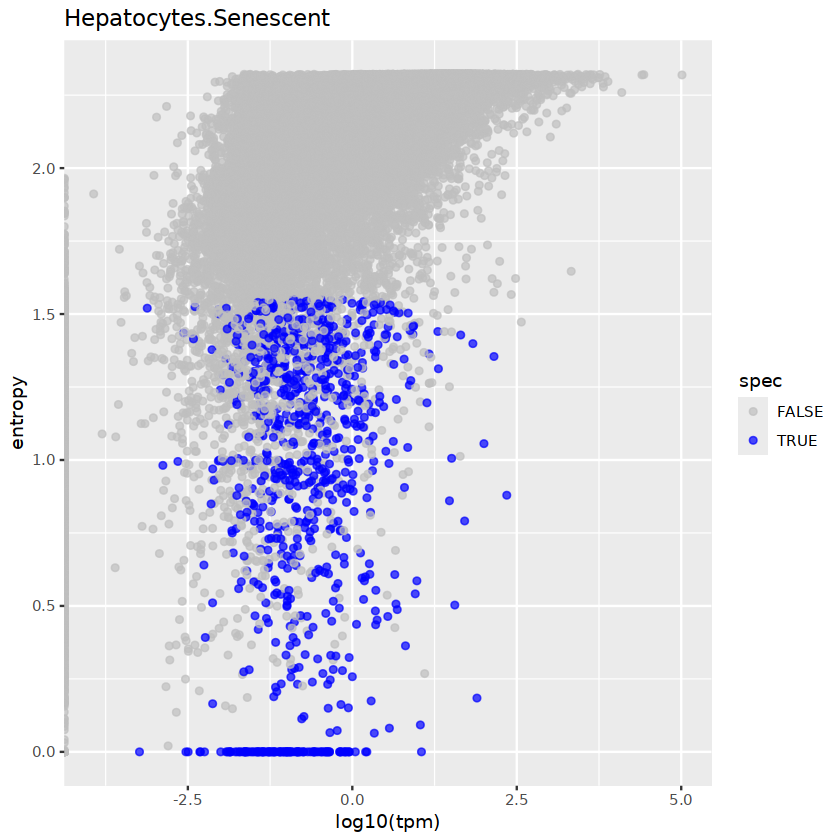

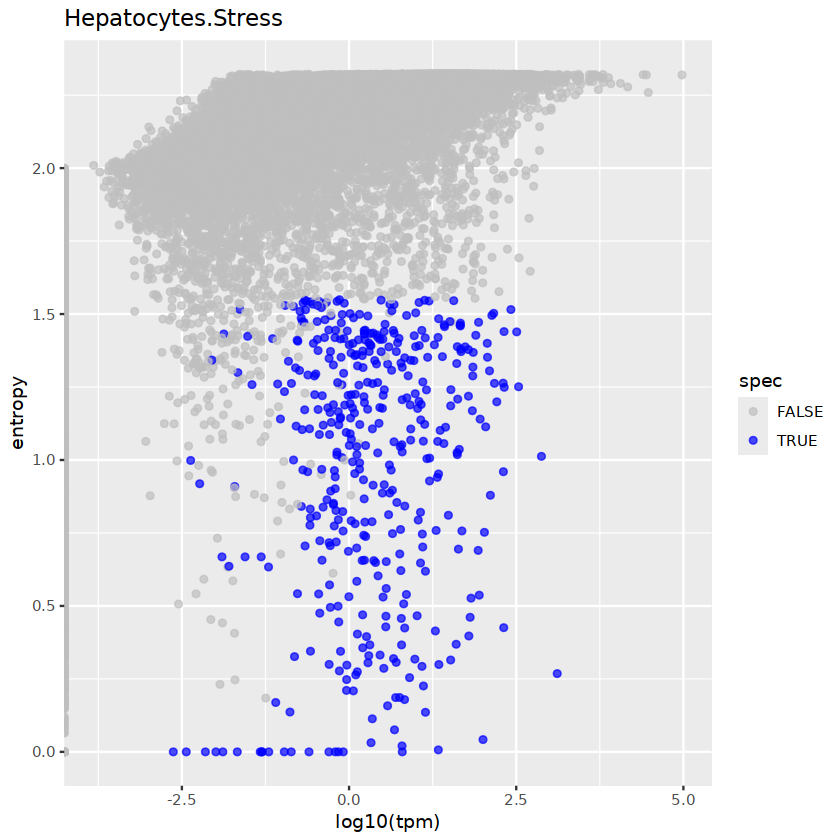

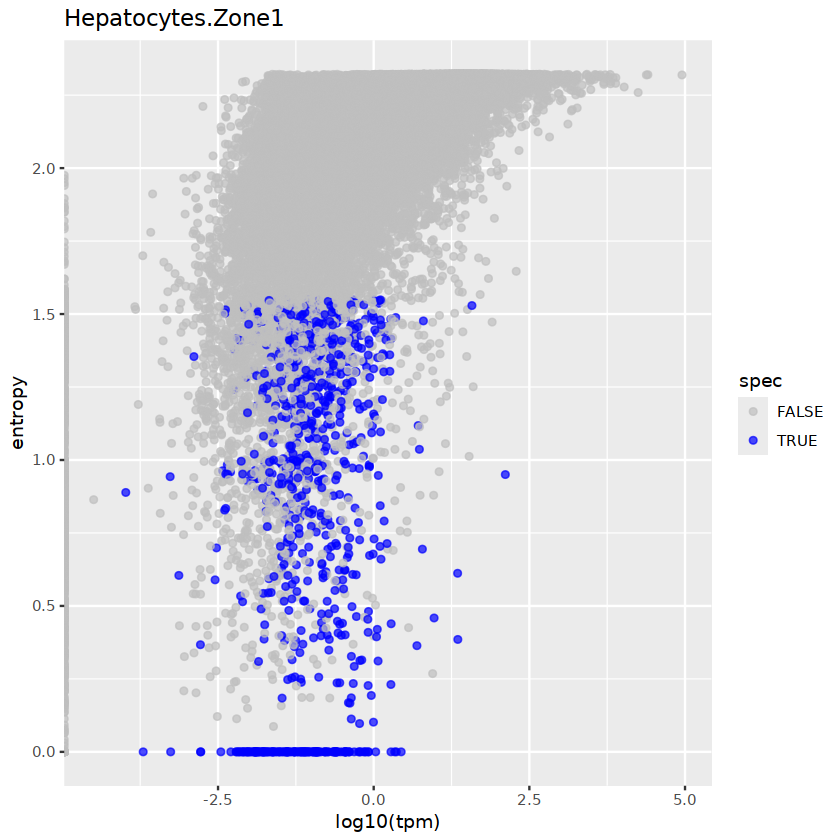

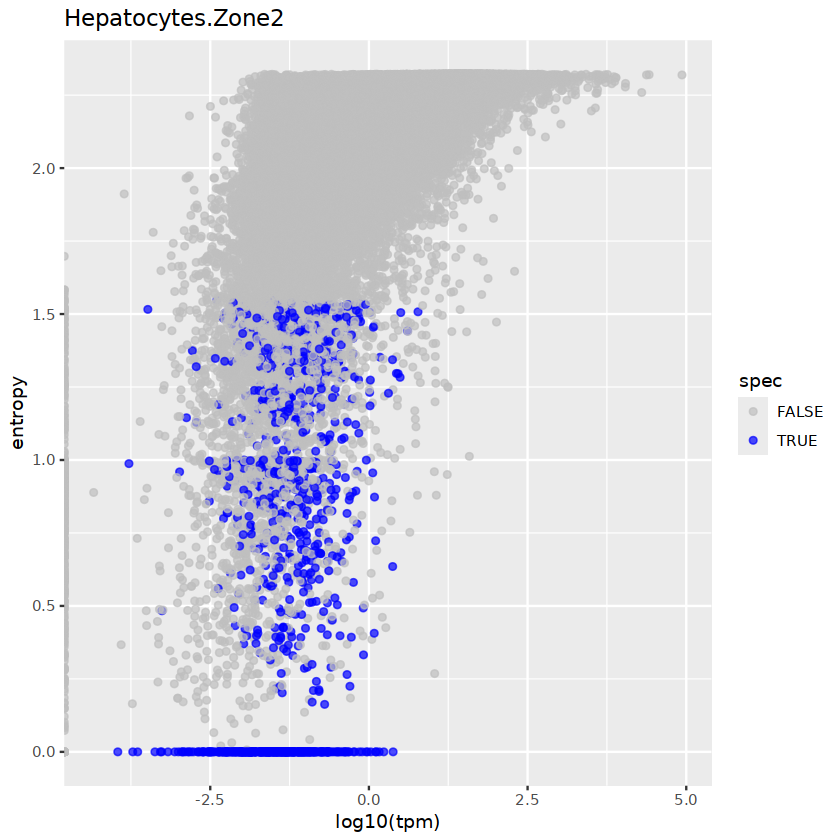

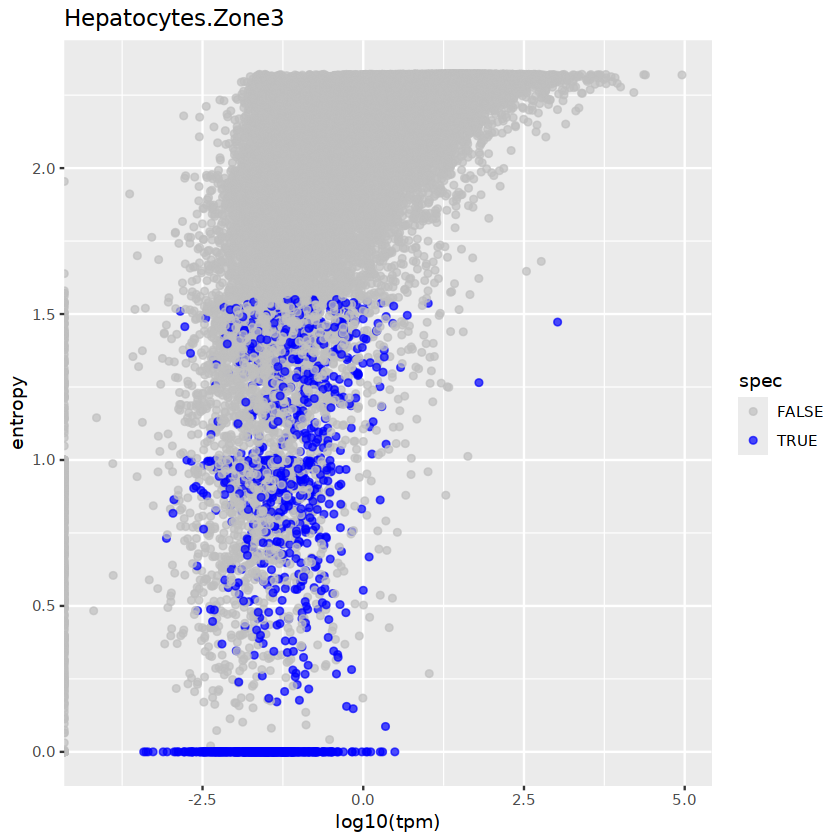

In [63]:
#quick plots to visualize TPM and entropy for cell type peaks
for(celltype in joint_celltypes){
    fp <- file.path(outdir,'RNA_ct_spec_genes',sprintf('%s_entropy2_genes.txt',celltype))
    df <- read.table(fp, sep='\t', header=1)
    data <- data.frame(tpm=tpm_fin[,celltype],entropy=entropy,spec=row.names(tpm_fin) %in% df$gene)
    
    p1 <- ggplot(data, aes(x=log10(tpm), y=entropy, color=spec)) + 
            geom_point(alpha=0.7) + ggtitle(celltype) + 
            scale_color_manual(values=c('TRUE'='blue','FALSE'='grey'))
    print(p1)
}

# Filter and export entropy_outputs

### RNA

In [69]:
# Define file paths
file_paths <- list.files(path = "/nfs/lab/mkim/Liver_Multiome/downstream/entropy_outputs/Hepatocytes/RNA_ct_spec_genes/", 
                         pattern = "*_entropy2_genes_TPM1.txt", full.names = TRUE)

# Initialize an empty list to store the gene columns and data frames for each cell type
data_list <- list()
all_genes <- c()

# Loop over file paths to read in data
for (file_path in file_paths) {
    # Extract cell type from the file name
    cell_type <- gsub("_entropy2_genes_TPM1.txt", "", basename(file_path))

    # Read the data
    data <- read.table(file_path, header = TRUE, sep = "", stringsAsFactors = FALSE)

    # Store the data frame in the list with the cell type as the key
    data_list[[cell_type]] <- data

    # Append the genes to a master list of all genes across cell types
    all_genes <- c(all_genes, data$gene)
}

In [70]:
# Count occurrences of each gene across all cell types
gene_counts <- table(all_genes)

In [71]:
# Initialize an empty list to store unique genes for each cell type
unique_genes_list <- list()

# Loop over each cell type's data and filter for unique genes
for (cell_type in names(data_list)) {
    # Get the data for this cell type
    data <- data_list[[cell_type]]

    # Filter for genes that are unique to this cell type (appearing only once across all cell types)
    unique_genes <- data[data$gene %in% names(gene_counts[gene_counts == 1]), ]

    # Store the filtered unique genes in the list
    unique_genes_list[[cell_type]] <- unique_genes

    # Save the unique genes table as a CSV file for each cell type
    write.csv(unique_genes, file = paste0("/nfs/lab/mkim/Liver_Multiome/downstream/entropy_outputs/Hepatocytes/RNA_ct_spec_genes/", cell_type, "_unique_genes.csv"), row.names = FALSE)
}

In [72]:
# Define file paths
file_paths <- list.files(path = "/nfs/lab/mkim/Liver_Multiome/downstream/entropy_outputs/Hepatocytes/RNA_ct_spec_genes/", 
                         pattern = "*_entropy2_genes_TPM1.txt", full.names = TRUE)

# Initialize an empty list to store the gene columns and data frames for each cell type
data_list <- list()
all_genes <- c()

# Loop over file paths to read in data
for (file_path in file_paths) {
    # Extract cell type from the file name
    cell_type <- gsub("_entropy2_genes_TPM1.txt", "", basename(file_path))

    # Read the data
    data <- read.table(file_path, header = TRUE, sep = "", stringsAsFactors = FALSE)

    # Store the data frame in the list with the cell type as the key
    data_list[[cell_type]] <- data

    # Append the genes to a master list of all genes across cell types
    all_genes <- c(all_genes, data$gene)
}

# Count occurrences of each gene across all cell types
gene_counts <- table(all_genes)

# Initialize an empty data frame to store all unique genes and their associated cell types
consolidated_unique_genes <- data.frame(gene = character(), cell_type = character(), stringsAsFactors = FALSE)

# Loop over each cell type's data and filter for unique genes
for (cell_type in names(data_list)) {
    # Get the data for this cell type
    data <- data_list[[cell_type]]

    # Filter for genes that are unique to this cell type (appearing only once across all cell types)
    unique_genes <- data[data$gene %in% names(gene_counts[gene_counts == 1]), ]

    # Add the cell type as a new column to the unique genes
    unique_genes$cell_type <- cell_type

    # Append the unique genes to the consolidated table
    consolidated_unique_genes <- rbind(consolidated_unique_genes, unique_genes)
}

# Save the consolidated table to a CSV file
write.csv(consolidated_unique_genes, file = "/nfs/lab/mkim/Liver_Multiome/downstream/entropy_outputs/Hepatocytes/Hepatocytes_RNA_ct_specific_genes_all.csv", row.names = FALSE)


In [73]:
# Rearrange columns in the desired order: gene, cell_type, entropy, ct_cpm
consolidated_unique_genes <- consolidated_unique_genes[, c("gene", "cell_type", "entropy", "ct_cpm")]

# Rename the 'ct_cpm' column to 'ct_tpm'
colnames(consolidated_unique_genes)[colnames(consolidated_unique_genes) == "ct_cpm"] <- "ct_tpm"

# Sort the rows by descending 'ct_tpm' values
consolidated_unique_genes <- consolidated_unique_genes[order(-consolidated_unique_genes$ct_tpm), ]

# Save the final table to a CSV file
    write.csv(consolidated_unique_genes, file = "/nfs/lab/mkim/Liver_Multiome/downstream/entropy_outputs/Hepatocytes/Hepatocytes_RNA_ct_specific_genes_all.csv", row.names = FALSE)


In [74]:
head(consolidated_unique_genes, n=50)

,gene,cell_type,entropy,ct_tpm
,<chr>,<chr>,<dbl>,<dbl>
125,STEAP4,Hepatocytes.Stress,0.26816697,1296.91465
466,CYP3A4,Hepatocytes.Zone3,1.47244678,1054.96192
126,AC127024.5,Hepatocytes.Stress,1.01241129,753.26929
127,AC107952.2,Hepatocytes.Stress,1.25090138,342.95524
128,AC068790.4,Hepatocytes.Stress,1.43892180,321.35647
129,AL451050.2,Hepatocytes.Stress,1.51530109,263.30720
1,CXCL8,Hepatocytes.Senescent,0.87926900,222.85740
130,AL159972.1,Hepatocytes.Stress,1.24888570,209.22837
131,AC022306.3,Hepatocytes.Stress,1.43990598,207.73977


## Top 500 lowest entropy genes & TPM>1

In [14]:
# Define file paths
file_paths <- list.files(path = "/nfs/lab/mkim/Liver_Multiome/downstream/entropy_outputs/Hepatocytes/RNA_ct_spec_genes/", 
                         pattern = "*_entropy2_genes_noCUToff.txt", full.names = TRUE)

# Initialize an empty list to store the data frames for each cell type
data_list <- list()

# Loop over file paths to read in data
for (file_path in file_paths) {
    # Extract cell type from the file name
    cell_type <- gsub("_entropy2_genes_noCUToff.txt", "", basename(file_path))

    # Read the data
    data <- read.table(file_path, header = TRUE, sep = "", stringsAsFactors = FALSE)

    # Store the data frame in the list with the cell type as the key
    data_list[[cell_type]] <- data
}

# Initialize an empty data frame to store the top 5000 peaks with lowest entropy and ct_cpm > 5
consolidated_top_genes <- data.frame(gene = character(), entropy = numeric(), ct_cpm = numeric(), cell_type = character(), stringsAsFactors = FALSE)

# Loop over each cell type's data to filter for ct_cpm > 5 and include the top 5000 peaks with the lowest entropy
for (cell_type in names(data_list)) {
    # Get the data for this cell type
    data <- data_list[[cell_type]]

    # Filter for peaks with ct_tpm > 1
    data_filtered <- data[data$ct_cpm > 1, ]

    # Sort the filtered data by entropy in ascending order
    data_sorted <- data_filtered[order(data_filtered$entropy), ]

    # Select the top 500 peaks with the lowest entropy
    top_genes <- head(data_sorted, 500)

    # Add the cell type as a new column to the top peaks
    top_genes$cell_type <- cell_type

    # Append the top peaks to the consolidated table
    consolidated_top_genes <- rbind(consolidated_top_genes, top_genes[, c("gene", "entropy", "ct_cpm", "cell_type")])
}

# The consolidated_top_peaks data frame now contains the top 5000 peaks with the lowest entropy and ct_cpm > 5 for each cell type

# Rearrange columns in the desired order: peak, cell_type, entropy, ct_cpm, unique_to_cell_type
consolidated_top_genes <- consolidated_top_genes[, c("gene", "cell_type", "entropy", "ct_cpm")]

# Sort the rows by descending 'ct_cpm' values
consolidated_top_genes <- consolidated_top_genes[order(-consolidated_top_genes$ct_cpm), ]

# Rename the 'ct_cpm' column to 'ct_tpm'
colnames(consolidated_top_genes)[colnames(consolidated_top_genes) == "ct_cpm"] <- "ct_tpm"

dim(consolidated_top_genes)
head(consolidated_top_genes)
consolidated_top_genes %>% count(cell_type)

# Save the final table to a CSV file
write.csv(consolidated_top_genes, file = "/nfs/lab/mkim/Liver_Multiome/downstream/entropy_outputs/Hepatocytes/Hepatocytes_RNA_ct_specific_genes_noCUToff_TPM1_all.csv", row.names = FALSE)


[1] 2500    4

,gene,cell_type,entropy,ct_tpm
,<chr>,<chr>,<dbl>,<dbl>
3022,MT-ND3,Hepatocytes.Zone2,2.206055,3697.4765
2989,MT-ATP6,Hepatocytes.Zone2,2.195824,3200.6285
1027,SERPINE1,Hepatocytes.Senescent,1.646387,2125.3930
38,STEAP4,Hepatocytes.Stress,0.268167,1296.9146
12041,CYP3A4,Hepatocytes.Zone3,1.472447,1054.9619
177,AC127024.5,Hepatocytes.Stress,1.012411,753.2693


cell_type,n
<chr>,<int>
Hepatocytes.Senescent,500
Hepatocytes.Stress,500
Hepatocytes.Zone1,500
Hepatocytes.Zone2,500
Hepatocytes.Zone3,500
